# Modelado de Series Temporales con Redes Neuronales Recurrentes (LSTM)
En esta sección, implementamos un enfoque de aprendizaje supervisado utilizando una red **LSTM (Long Short-Term Memory)** en Keras/TensorFlow. Analizaremos el ticker de **PepsiCo (PEP)**. El objetivo es transformar la serie temporal en un formato supervisado mediante una ventana deslizante de tamaño $n=10$ para predecir el precio del siguiente día ($t+1$).

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from keras.callbacks import EarlyStopping
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# 1. Descarga de una serie de tiempo diferente (PepsiCo - PEP)
TICKER_DL = "PEP"
FECHA_INICIO = "2024-01-01"
FECHA_FIN = "2026-01-01"

print(f"Descargando datos para {TICKER_DL}...")
df_pep = yf.download(
    TICKER_DL, start=FECHA_INICIO, end=FECHA_FIN, group_by="ticker"
)

# Extraer precios de cierre de forma robusta ante estructuras MultiIndex
if isinstance(df_pep.columns, pd.MultiIndex):
    serie_pep = df_pep[TICKER_DL]['Close'].dropna()
else:
    serie_pep = df_pep["Close"].dropna()

print(f"Datos cargados con éxito. Total de días bursátiles: {len(serie_pep)}")

Descargando datos para PEP...


[*********************100%***********************]  1 of 1 completed

Datos cargados con éxito. Total de días bursátiles: 502


In [11]:
# 2. Estandarización de datos (Escalar entre 0 y 1 para la sensibilidad de la LSTM)
scaler = MinMaxScaler(feature_range=(0, 1))
# Reshape necesario ya que el MinMaxScaler requiere una matriz bidimensional (N, 1)
precios_valores = serie_pep.values.reshape(-1, 1)
precios_escalados = scaler.fit_transform(precios_valores)


# 3. Conversión de la serie de tiempo a formato supervisado (Ventana Deslizante)
def crear_formato_supervisado(data, tamano_ventana=10):
    """Crea pares de entrada-salida (X, y) donde:

    X = [t_1, t_2, ..., t_n] (Entrada de tamaño n) y = t_{n+1} (Salida: Un solo
    paso hacia adelante)
    """
    X, y = [], []
    for i in range(len(data) - tamano_ventana):
        # Tomar los n pasos anteriores como entrada
        X.append(data[i : (i + tamano_ventana), 0])
        # Tomar el paso n+1 como la salida objetivo
        y.append(data[i + tamano_ventana, 0])
    return np.array(X), np.array(y)


TAMANO_VENTANA = 10
X, y = crear_formato_supervisado(
    precios_escalados, tamano_ventana=TAMANO_VENTANA
)

# Formatear X para que sea compatible con LSTM: [Muestras, Pasos de tiempo, Características]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(f"Estructura de los datos para entrenamiento:")
print(
    f"Forma de X (Entradas): {X.shape} -> {X.shape[0]} muestras de {X.shape[1]} días cada una."
)
print(
    f"Forma de y (Salidas):  {y.shape} -> {y.shape[0]} valores objetivo correspondientes."
)

Estructura de los datos para entrenamiento:
Forma de X (Entradas): (492, 10, 1) -> 492 muestras de 10 días cada una.
Forma de y (Salidas):  (492,) -> 492 valores objetivo correspondientes.


In [12]:
# Aquí dividimos los datos de forma cronológica (80% entrenamiento, 20% prueba)
CORTE = int(len(X) * 0.8)

X_train, X_test = X[:CORTE], X[CORTE:]
y_train, y_test = y[:CORTE], y[CORTE:]

print(
    f"Datos de entrenamiento: {X_train.shape}, Datos de prueba: {X_test.shape}"
)

# MEJORA: Añadimos Early Stopping para evitar entrenar de más si el error ya no baja
# Si el loss de validación no mejora en 5 épocas, se detiene y recupera los mejores pesos.
early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

# --- Construcción de la Red Neuronal ---
# Se uso el enfoque secuencial añadiendo capa por capa con .add()
modelo_lstm = Sequential()

# Primera capa: LSTM con 50 unidades y activación tanh
modelo_lstm.add(
    LSTM(
        units=50,
        activation="tanh",
        input_shape=(TAMANO_VENTANA, 1),
        return_sequences=False,
    )
)

# Se añadio una capa de Dropout para regularizar la red y mitigar el overfitting
modelo_lstm.add(Dropout(0.2))

# Capa de salida para regresión (1 sola neurona)
modelo_lstm.add(Dense(units=1))

# Compilación usando Adam y Error Cuadrático Medio
modelo_lstm.compile(optimizer="adam", loss="mean_squared_error")

# Revisamos la arquitectura resultante
print("\n--- RESUMEN DEL MODELO ---")
modelo_lstm.summary()

# --- Entrenamiento ---
print("\nIniciando el entrenamiento de la LSTM...")
history = modelo_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=40,  # Se sube a 40 porque el Early Stopping controlará el final óptimo
    batch_size=16,
    callbacks=[early_stop],
    verbose=1,
)

Datos de entrenamiento: (393, 10, 1), Datos de prueba: (99, 10, 1)


C:\Users\joelr\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- RESUMEN DEL MODELO ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando el entrenamiento de la LSTM...
Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.1113 - val_loss: 0.0160
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0126 - val_loss: 0.0060
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0110 - val_loss: 0.0052
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0099 - val_loss: 0.0054
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0097 - val_loss: 0.0054
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0080 - val_loss: 0.0054
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0072 - val_loss: 0.0053
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0073 - val_loss: 0.0053


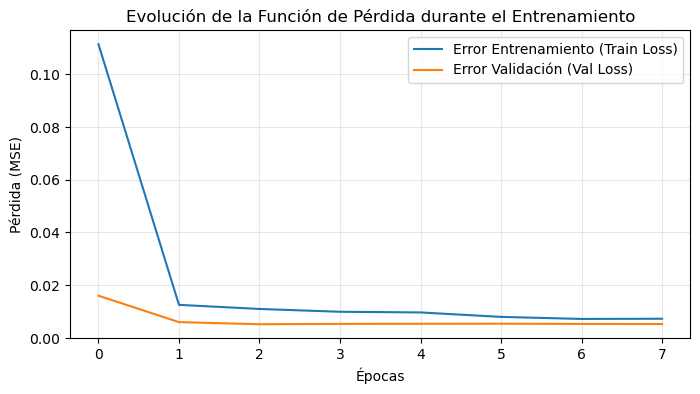

In [ ]:
# Graficar las curvas de pérdida para evaluar el aprendizaje de la red
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Error Entrenamiento (Train Loss)")
plt.plot(history.history["val_loss"], label="Error Validación (Val Loss)")
plt.title("Evolución de la Función de Pérdida durante el Entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (MSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Calculando las predicciones sobre el conjunto de test...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step

*********************************************
     RESULTADOS DE LA EVALUACIÓN (LSTM)     
*********************************************
-> Error Cuadrático Medio (MSE): 11.2524
-> Error Absoluto Medio (MAE):  2.72 USD
*********************************************
Nota analítica: En promedio, el modelo difiere por 2.72 dólares
respecto al precio de cierre real de la acción.
*********************************************

Generando gráfica de rendimiento...


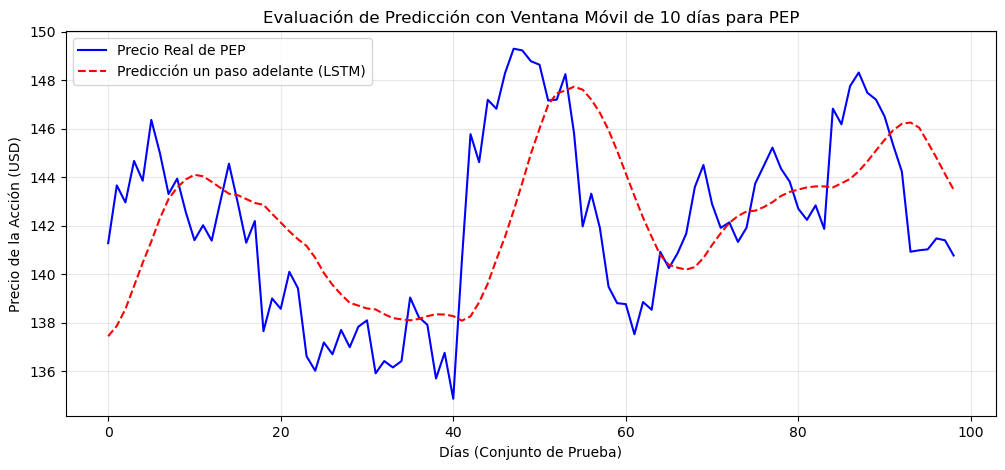


¡Práctica y evaluación completadas exitosamente!


In [14]:
print("Calculando las predicciones sobre el conjunto de test...")
predicciones_escaladas = modelo_lstm.predict(X_test)

# Invertir el escalado para regresar los datos a su escala original en USD
predicciones_reales = scaler.inverse_transform(predicciones_escaladas)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calcular el MSE y MAE de forma consistente usando las matrices desescaladas
mse = mean_squared_error(y_test_real, predicciones_reales)
mae = mean_absolute_error(y_test_real, predicciones_reales)

print("\n" + "*" * 45)
print("     RESULTADOS DE LA EVALUACIÓN (LSTM)     ")
print("*" * 45)
print(f"-> Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"-> Error Absoluto Medio (MAE):  {mae:.2f} USD")
print("*" * 45)
print(
    f"Nota analítica: En promedio, el modelo difiere por {mae:.2f} dólares"
)
print("respecto al precio de cierre real de la acción.")
print("*" * 45)

# --- Gráfica Comparativa Final ---
print("\nGenerando gráfica de rendimiento...")
plt.figure(figsize=(12, 5))
plt.plot(y_test_real, label="Precio Real de PEP", color="blue", linewidth=1.5)
plt.plot(
    predicciones_reales,
    label="Predicción un paso adelante (LSTM)",
    color="red",
    linestyle="--",
    linewidth=1.5,
)
plt.title(
    f"Evaluación de Predicción con Ventana Móvil de {TAMANO_VENTANA} días para {TICKER_DL}"
)
plt.xlabel("Días (Conjunto de Prueba)")
plt.ylabel("Precio de la Acción (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n¡Práctica y evaluación completadas exitosamente!")